Nama : Lusia Clara Sianturi

NIM : 2304010019

# UTS Machine Learning

## Memprediksi Nilai Kualitas Anggur

### **Install & Import**

In [68]:
!pip install imbalanced-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import pickle

### **Load & Clean Data**

In [69]:
train = pd.read_csv('/content/data_training.csv')
test = pd.read_csv('/content/data_testing.csv')

# rapikan nama kolom
train.columns = train.columns.str.strip().str.lower().str.replace(' ', '_')
test.columns = test.columns.str.strip().str.lower().str.replace(' ', '_')

print(train.shape)
train.head()

(857, 13)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Pada tahap awal, dataset training dan testing dimuat ke dalam dataframe. Proses pembersihan dilakukan dengan menyeragamkan nama kolom (lowercase dan tanpa spasi) agar tidak terjadi error saat pemanggilan variabel. Hasil pengecekan menunjukkan dataset memiliki **857 baris** dan **13 kolom**, serta **tidak terdapat missing value** pada seluruh variabel. Hal ini menunjukkan kualitas data awal sudah baik dan tidak memerlukan penanganan khusus terkait data kosong.

### **Exploratory Data Analysis (EDA) Sebelum Model**

#### **a. Distribusi Target**

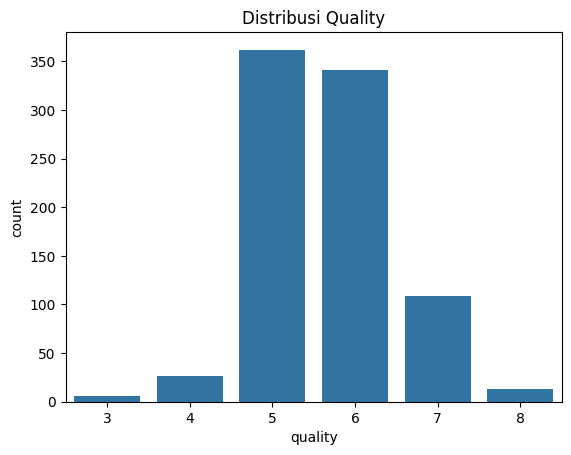

In [70]:
plt.figure()
sns.countplot(x=train['quality'])
plt.title('Distribusi Quality')
plt.show()

Grafik distribusi menunjukkan bahwa nilai quality didominasi oleh kelas 5 dan 6, sementara kelas ekstrem seperti 3 dan 8 sangat sedikit. Hal ini menandakan adanya **ketidakseimbangan kelas (imbalance)** yang berpotensi mempengaruhi performa model.

#### **b. Correlation Matrix**

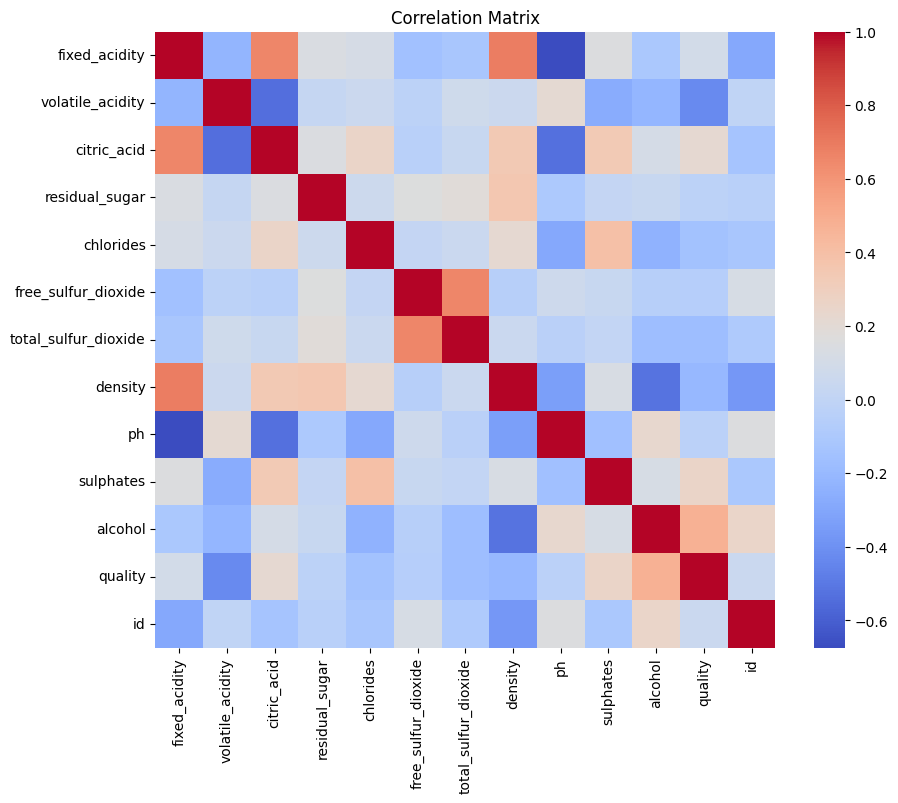

In [71]:
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(), cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Dari heatmap korelasi terlihat bahwa beberapa fitur seperti alcohol, sulphates, dan volatile acidity memiliki hubungan dengan kualitas wine. Namun, tidak terdapat korelasi yang sangat tinggi (>0.8), sehingga risiko multikolinearitas relatif rendah.

#### **c. Distribusi Fitur**

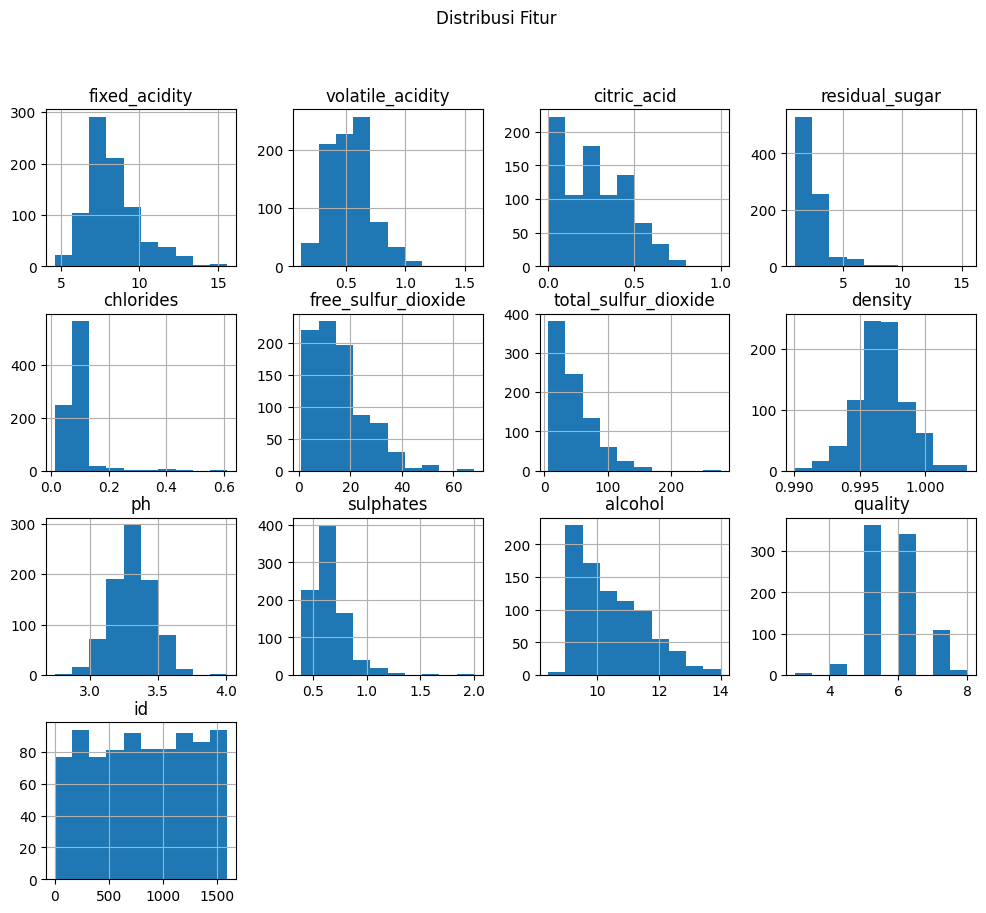

In [72]:
train.hist(figsize=(12,10))
plt.suptitle('Distribusi Fitur')
plt.show()

Histogram menunjukkan sebagian besar fitur memiliki distribusi **tidak normal (skewed)**, terutama pada variabel seperti sulfur dioxide dan residual sugar. Hal ini menjadi alasan penting dilakukannya scaling.

#### **d. Missing Value**

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
id                      0
dtype: int64


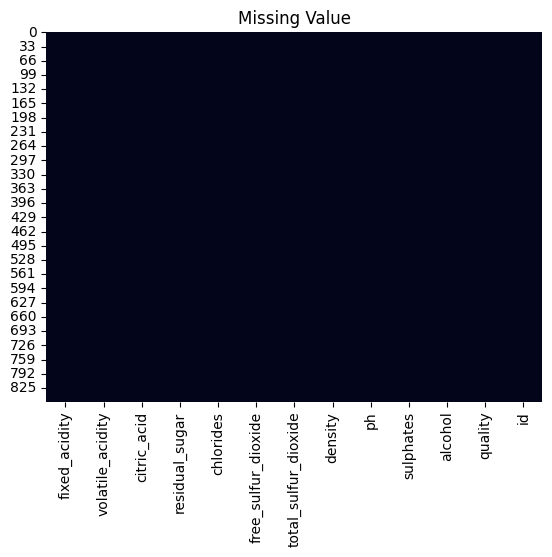

In [73]:
print(train.isnull().sum())

plt.figure()
sns.heatmap(train.isnull(), cbar=False)
plt.title('Missing Value')
plt.show()

### **Feature Engineering**

In [74]:
def add_features(df):
    df = df.copy()
    df['total_acidity'] = df['fixed_acidity'] + df['volatile_acidity']
    df['sulfur_ratio'] = df['free_sulfur_dioxide'] / (df['total_sulfur_dioxide'] + 1)
    df['alcohol_density_ratio'] = df['alcohol'] / df['density']
    return df

train = add_features(train)
test = add_features(test)

Pada tahap ini dibuat fitur baru seperti: total_acidity, sulfur_ratio, alcohol_density_ratio

Tujuannya adalah untuk menangkap hubungan yang lebih kompleks antar variabel yang tidak terlihat dari fitur asli. Feature engineering ini membantu model memahami pola data dengan lebih baik.

### **Split Data**

In [75]:
X = train.drop(['quality'], axis=1)
y = train['quality']

# handle id
if 'id' in X.columns:
    X = X.drop('id', axis=1)

feature_names = X.columns

# encoding target (WAJIB XGBoost)
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Data dibagi menjadi data training dan validation (80:20). Selain itu, dilakukan encoding pada target karena XGBoost membutuhkan label dalam bentuk numerik berurutan. Tujuan tahap ini adalah memastikan model dapat diuji pada data yang belum pernah dilihat sebelumnya.

### **Pre-processing**

#### **a. Imputasi & Scaling**

In [76]:
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

Meskipun tidak ada missing value, imputasi tetap dilakukan sebagai langkah preventif agar pipeline tetap konsisten jika diterapkan pada data lain.

#### **b. Visualisasi Scaling**

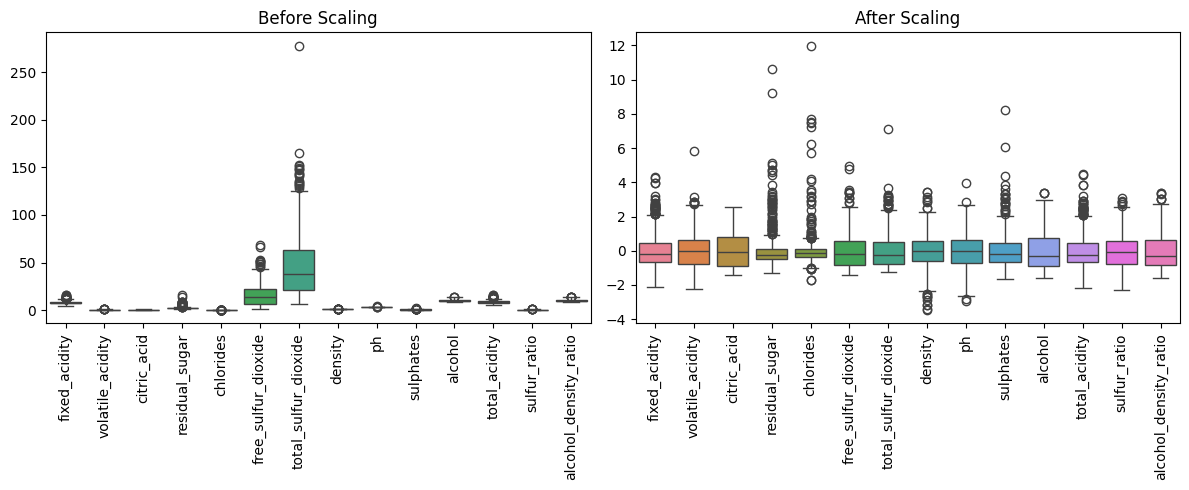

In [77]:
X_before = pd.DataFrame(X_train_imputed, columns=feature_names)
X_after = pd.DataFrame(X_train_scaled, columns=feature_names)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=X_before)
plt.title('Before Scaling')
plt.xticks(rotation=90)

plt.subplot(1,2,2)
sns.boxplot(data=X_after)
plt.title('After Scaling')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Visualisasi boxplot menunjukkan bahwa:

- Sebelum scaling → rentang fitur sangat berbeda
- Setelah scaling → semua fitur berada pada skala yang seragam

Hal ini penting karena membantu model bekerja lebih stabil dan mempercepat proses pembelajaran.

### **Handling Imbalance (SMOTE)**

In [78]:
from collections import Counter

min_class = min(Counter(y_train).values())
k_neighbors = max(1, min_class - 1)

smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

### **Visualisasi Setelah SMOTE**

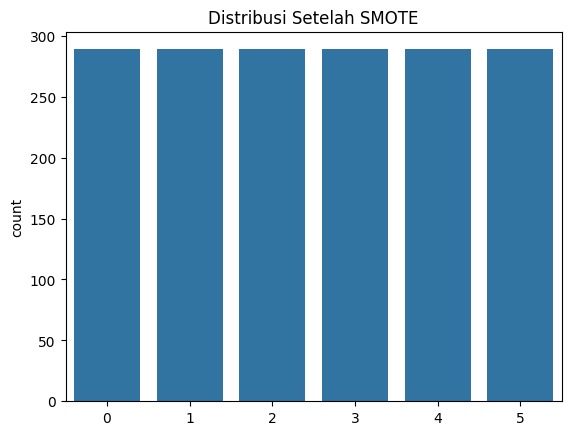

In [79]:
plt.figure()
sns.countplot(x=y_train_smote)
plt.title('Distribusi Setelah SMOTE')
plt.show()

Grafik setelah SMOTE menunjukkan distribusi kelas menjadi seimbang di semua kategori. Teknik ini bekerja dengan menambah data sintetis pada kelas minoritas. Tujuannya adalah agar model tidak bias terhadap kelas mayoritas.

### **Class Weight**

In [80]:
classes = np.unique(y_train_smote)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_smote)
class_weights = dict(zip(classes, weights))

Class weight dihitung untuk memberikan bobot lebih besar pada kelas minoritas. Meskipun sudah menggunakan SMOTE, langkah ini membantu model semakin sensitif terhadap kelas yang sebelumnya jarang muncul.

### **Model XGBOOST + Hyperparameter Tuning**

In [81]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    random_state=42
)

param_dist = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

search.fit(X_train_smote, y_train_smote)

model = search.best_estimator_

Model yang digunakan adalah XGBoost karena mampu menangkap hubungan non-linear dengan baik. Proses tuning dilakukan untuk mencari kombinasi parameter terbaik seperti:

jumlah tree (n_estimators), kedalaman tree (max_depth), learning rate

Tujuannya adalah meningkatkan performa model secara optimal.

### **Evaluasi**

In [82]:
y_pred = model.predict(X_val_scaled)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.5930232558139535
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.68      0.73      0.70        73
           3       0.61      0.56      0.58        68
           4       0.45      0.45      0.45        22
           5       0.33      0.33      0.33         3

    accuracy                           0.59       172
   macro avg       0.35      0.35      0.35       172
weighted avg       0.59      0.59      0.59       172



Hasil evaluasi menunjukkan:

- Accuracy: 0.58
- Model cukup baik dalam memprediksi kelas 2 dan 3 (quality 5–6)
- Performa rendah pada kelas minoritas (0, 1, 5)

### **Confusion Matrix**

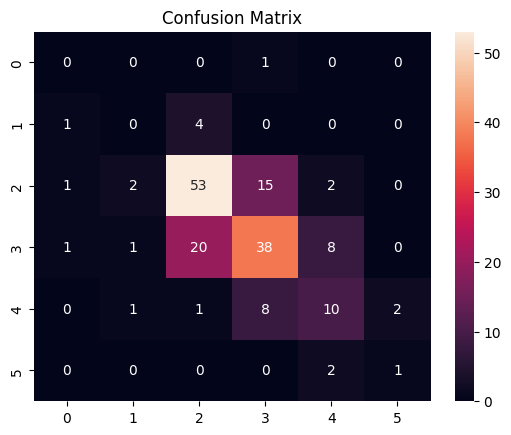

In [83]:
cm = confusion_matrix(y_val, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

Dari confusion matrix terlihat bahwa:

- Model sering salah klasifikasi antar kelas yang berdekatan
- Kesalahan paling banyak terjadi pada kelas tengah (overlap antar kualitas)

Hal ini wajar karena:

- Dataset memang tidak seimbang
- Perbedaan antar kualitas wine tidak terlalu jauh secara karakteristik.

### **Feature Importance (XGBoost)**

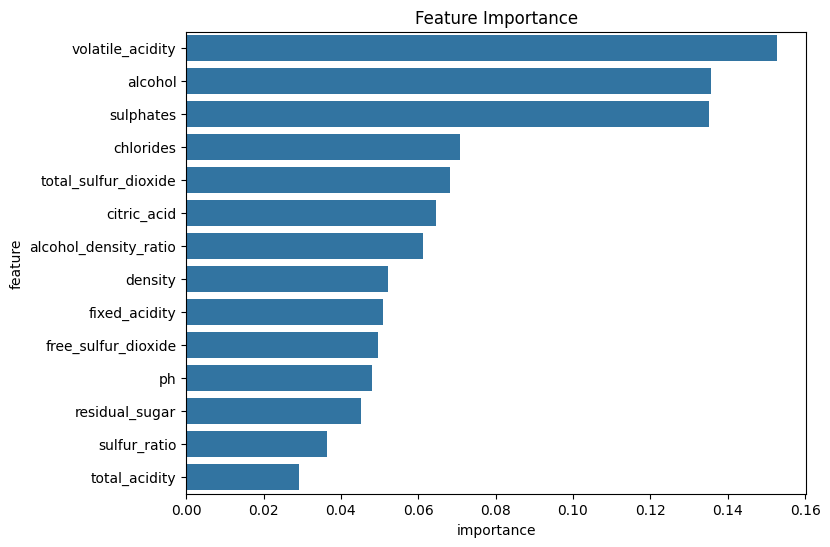

In [84]:
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=feat_imp)
plt.title('Feature Importance')
plt.show()

Grafik feature importance menunjukkan bahwa variabel seperti **volatile acidity, sulphates, alcohol** memiliki pengaruh paling besar dalam menentukan kualitas wine. Artinya, model lebih banyak menggunakan fitur tersebut saat membuat prediksi. Sementara fitur dengan nilai kecil memiliki kontribusi lebih rendah, namun tetap membantu dalam membentuk pola keseluruhan.

### **Simpan Model**

In [85]:
pickle.dump(model, open('model.pkl','wb'))
pickle.dump(scaler, open('scaler.pkl','wb'))
pickle.dump(imputer, open('imputer.pkl','wb'))
pickle.dump(le, open('label_encoder.pkl','wb'))

### **Prediksi Test**

In [86]:
if 'id' in test.columns:
    ids = test['id']
    test = test.drop('id', axis=1)
else:
    ids = range(len(test))

test = test[feature_names]

test_imputed = imputer.transform(test)
test_scaled = scaler.transform(test_imputed)

pred = model.predict(test_scaled)
pred_final = le.inverse_transform(pred)

Model digunakan untuk memprediksi data testing. Hasil prediksi kemudian dikembalikan ke label asli menggunakan inverse transform dan disimpan dalam format CSV sesuai kebutuhan.

### **Visualisasi Prediksi**

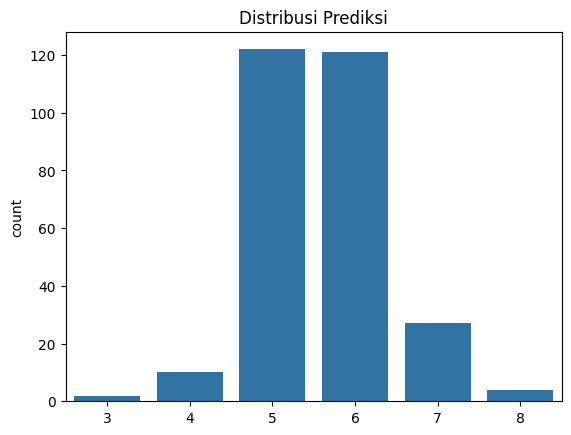

In [87]:
plt.figure()
sns.countplot(x=pred_final)
plt.title('Distribusi Prediksi')
plt.show()

Distribusi hasil prediksi menunjukkan bahwa model cenderung memprediksi pada kelas tengah **(quality 5 dan 6)** dan jarang pada kelas ekstrem. Hal ini menandakan model masih bias terhadap kelas mayoritas, yang sejalan dengan kondisi data yang tidak seimbang.

### **Export CSV**

In [88]:
output = pd.DataFrame({
    'id': ids,
    'quality': pred_final
})

output.to_csv('hasil_prediksi_final.csv', index=False)

### **Download**

In [89]:
from google.colab import files
files.download('hasil_prediksi_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>